# ConvLSTM (PyTorch / MPS) — lag features: surface + shallow θ (0–200 m)

**Idea:** feed a **3-day sequence** (`t−2`, `t−1`, `t`) into a **ConvLSTM** so the model sees recent surface forcing and upper-ocean memory. Runs on **Apple GPU via MPS** (no `tensorflow-metal`).

**Daily ops:** the model runs every day, so tomorrow you have **yesterday’s prediction**, not GLORYS. Training still uses true lag θ (teacher forcing). §6 is the fair test: roll forward on val using **own** shallow θ.

| Timestep | Channels (19) | Notes |
|----------|-----------------|-------|
| `t−2`, `t−1` | 8 surface + **11 shallow `thetao` (0–200 m)** | train: GLORYS (teacher forcing); ops: previous predictions |
| `t` (today) | 8 surface + **11 zeros** | no same-day shallow θ → avoids target leakage |

| Output Y | `(100, 240, 15)` | `thetao` at all 15 depths on day `t` |

**Shallow band (0–200 m):** `0, 5, 10, 20, 30, 50, 75, 100, 125, 150, 200` m

Samples skipped when lags cross a **season gap** (e.g. first days of January — no Dec 31 in the JFM cube).

Data: JFM 2015–2024 · time split 80/20 · masked MSE + L2 + early stopping.

Install once in this kernel if needed:
```python
%pip install torch
```

In [29]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import xarray as xr

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA = ROOT / "data" / "processed" / "train_daily_JFM_2015_2024"
RUN_TAG = "jfm_2015_2024_lag"
CKPT_DIR = ROOT / "ml" / "checkpoints"
OUT = ROOT / "outputs" / "convlstm_lag"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

SURFACE_CHANNELS = ["sst", "sss", "sla", "adt", "uo", "vo", "u10", "v10"]
SHALLOW_MAX_M = 200.0  # set to 50.0 for 0–50 m band only
LAG_OFFSETS = [2, 1, 0]  # days back from target day t
N_LAGS = len(LAG_OFFSETS)
MAX_LAG = max(LAG_OFFSETS)

print("PyTorch:", torch.__version__)
print("device:", DEVICE)
print("MPS available:", torch.backends.mps.is_available())
print("ROOT:", ROOT)
print("lags:", LAG_OFFSETS, "shallow ≤", SHALLOW_MAX_M, "m")

PyTorch: 2.13.0
device: mps
MPS available: True
ROOT: /Users/sayangarai/Documents/Programming/Projects/SIH_PS_26066
lags: [2, 1, 0] shallow ≤ 200.0 m


In [30]:
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch: int, hidden: int, k: int = 3):
        super().__init__()
        pad = k // 2
        self.hidden = hidden
        self.gates = nn.Conv2d(in_ch + hidden, 4 * hidden, k, padding=pad)

    def forward(self, x, state):
        h, c = state
        i, f, o, g = self.gates(torch.cat([x, h], dim=1)).chunk(4, dim=1)
        i, f, o = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
        g = torch.tanh(g)
        c = f * c + i * g
        h = o * torch.tanh(c)
        return h, c


class ConvLSTM2d(nn.Module):
    """PyTorch has no nn.ConvLSTM2d. Input (B, T, C, H, W) → seq + (h, c)."""

    def __init__(self, in_ch: int, hidden: int, k: int = 3, **_kwargs):
        super().__init__()
        self.cell = ConvLSTMCell(in_ch, hidden, k)
        self.hidden = hidden

    def forward(self, x, state=None):
        b, t, _, h, w = x.shape
        if state is None:
            z = torch.zeros(b, self.hidden, h, w, device=x.device, dtype=x.dtype)
            state = (z, z)
        hs = []
        for ti in range(t):
            state = self.cell(x[:, ti], state)
            hs.append(state[0])
        seq = torch.stack(hs, dim=1)
        h_n = state[0].unsqueeze(0)
        c_n = state[1].unsqueeze(0)
        return seq, (h_n, c_n)


class ConvLSTMLag(nn.Module):
    """(B, T, C, H, W) → (B, out_ch, H, W)."""

    def __init__(self, in_ch: int, out_ch: int = 15, hidden: int = 32):
        super().__init__()
        self.lstm0 = ConvLSTM2d(in_ch, hidden, 3)
        self.bn0 = nn.BatchNorm2d(hidden)
        self.lstm1 = ConvLSTM2d(hidden, hidden, 3)
        self.bn1 = nn.BatchNorm2d(hidden)
        self.lstm2 = ConvLSTM2d(hidden, hidden, 3)
        self.refine = nn.Conv2d(hidden, hidden, 3, padding=1)
        self.head = nn.Conv2d(hidden, out_ch, 1)

    def _bn_seq(self, bn: nn.BatchNorm2d, x: torch.Tensor) -> torch.Tensor:
        b, t, c, h, w = x.shape
        return bn(x.reshape(b * t, c, h, w)).reshape(b, t, c, h, w)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x, _ = self.lstm0(x)
        x = self._bn_seq(self.bn0, x)
        x, _ = self.lstm1(x)
        x = self._bn_seq(self.bn1, x)
        _, (h, _) = self.lstm2(x)
        last = h[-1]
        last = torch.relu(self.refine(last))
        return self.head(last)

## 1. Load cubes, shallow-depth indices, valid lag samples

In [31]:
surface = xr.open_dataset(DATA / "surface.nc", engine="h5netcdf")
target = xr.open_dataset(DATA / "target.nc", engine="h5netcdf")

depth_vals = target.depth.values.astype(np.float32)
shallow_idx = np.where(depth_vals <= SHALLOW_MAX_M)[0]
N_SHALLOW = len(shallow_idx)
N_IN = len(SURFACE_CHANNELS) + N_SHALLOW
N_OUT = len(depth_vals)

times = surface.time.values.astype("datetime64[D]")
n_days = len(times)
n_train = int(n_days * 0.8)
train_idx_raw = np.arange(0, n_train)
val_idx_raw = np.arange(n_train, n_days)

print(f"days: {n_days}  shallow depths ({N_SHALLOW}):", depth_vals[shallow_idx].tolist())
print(f"input channels / timestep: {N_IN}  (8 surface + {N_SHALLOW} shallow θ on lag days)")

days: 903  shallow depths (11): [0.0, 5.0, 10.0, 20.0, 30.0, 50.0, 75.0, 100.0, 125.0, 150.0, 200.0]
input channels / timestep: 19  (8 surface + 11 shallow θ on lag days)


In [32]:
def valid_lag_indices(indices: np.ndarray) -> np.ndarray:
    """Keep t only if every lag day is exactly 1 calendar day apart (no JFM season gaps)."""
    ok = []
    for t in indices:
        if t < MAX_LAG:
            continue
        good = True
        for lag in LAG_OFFSETS:
            tl = t - lag
            if lag > 0:
                delta = (times[t] - times[tl]) / np.timedelta64(1, "D")
                if int(delta) != lag:
                    good = False
                    break
        if good:
            ok.append(int(t))
    return np.array(ok, dtype=np.int32)


train_idx = valid_lag_indices(train_idx_raw)
val_idx = valid_lag_indices(val_idx_raw)

print(f"train: {len(train_idx_raw)} → {len(train_idx)} valid lag samples")
print(f"val:   {len(val_idx_raw)} → {len(val_idx)} valid lag samples")
print("train:", str(times[train_idx[0]])[:10], "→", str(times[train_idx[-1]])[:10])
print("val:  ", str(times[val_idx[0]])[:10], "→", str(times[val_idx[-1]])[:10])

train: 722 → 706 valid lag samples
val:   181 → 177 valid lag samples
train: 2015-01-03 → 2022-03-31
val:   2023-01-03 → 2024-03-31


## 2. Normalize (train ocean pixels only)

In [33]:
def channel_mean_std(arr: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    c = arr.shape[-1]
    mean = np.zeros(c, dtype=np.float32)
    std = np.ones(c, dtype=np.float32)
    for i in range(c):
        vals = arr[..., i][np.isfinite(arr[..., i])]
        if vals.size:
            mean[i] = vals.mean()
            s = vals.std()
            std[i] = s if s > 1e-6 else 1.0
    return mean, std


x_surface = np.stack([surface[name].values for name in SURFACE_CHANNELS], axis=-1).astype(np.float32)
y_all = np.moveaxis(target.thetao.values.astype(np.float32), 1, -1)
y_shallow = y_all[..., shallow_idx]

surf_mean, surf_std = channel_mean_std(x_surface[train_idx])
shallow_mean, shallow_std = channel_mean_std(y_shallow[train_idx])
y_mean, y_std = channel_mean_std(y_all[train_idx])

frame_mean = np.concatenate([surf_mean, shallow_mean]).astype(np.float32)
frame_std = np.concatenate([surf_std, shallow_std]).astype(np.float32)

H, W = x_surface.shape[1], x_surface.shape[2]
print("X surface", x_surface.shape, "Y", y_all.shape)
print("frame mean (surf + shallow):", np.round(frame_mean, 2))

X surface (903, 100, 240, 8) Y (903, 100, 240, 15)
frame mean (surf + shallow): [ 2.717e+01  3.459e+01  9.000e-02  8.700e-01 -8.000e-02  1.000e-02
 -2.060e+00 -2.600e+00  2.724e+01  2.716e+01  2.722e+01  2.726e+01
  2.726e+01  2.699e+01  2.582e+01  2.351e+01  2.086e+01  1.858e+01
  1.568e+01]


## 3. Lag sequences & DataLoader

In [ ]:
def build_frame(day_t: int, lag: int) -> np.ndarray:
    """One timestep: 8 surface + (shallow θ if lag>0 else zeros)."""
    tl = day_t - lag
    surf = x_surface[tl].astype(np.float32)
    if lag == 0:
        shallow = np.zeros((H, W, N_SHALLOW), dtype=np.float32)
    else:
        shallow = y_shallow[tl].astype(np.float32)
    return np.concatenate([surf, shallow], axis=-1)


def make_example(t: int):
    frames = np.stack([build_frame(t, lag) for lag in LAG_OFFSETS], axis=0)  # T,H,W,C
    y = y_all[t].copy()

    x_ok = np.all(np.isfinite(frames), axis=(0, 3))
    y_ok = np.isfinite(y)
    mask = (y_ok & x_ok[..., None]).astype(np.float32)

    frames = (frames - frame_mean) / frame_std
    y = (y - y_mean) / y_std
    frames = np.nan_to_num(frames, nan=0.0).astype(np.float32)
    y = np.nan_to_num(y, nan=0.0).astype(np.float32)
    frames = np.moveaxis(frames, -1, 1)  # T,C,H,W for PyTorch
    y = np.moveaxis(y, -1, 0)            # C,H,W
    mask = np.moveaxis(mask, -1, 0)
    return frames, y, mask


class LagDataset(Dataset):
    def __init__(self, indices: np.ndarray):
        self.indices = np.asarray(indices, dtype=np.int32)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x, y, m = make_example(int(self.indices[i]))
        return torch.from_numpy(x), torch.from_numpy(y), torch.from_numpy(m)


BATCH = 2  # ConvLSTM is heavy on MPS; bump if memory allows
train_loader = DataLoader(LagDataset(train_idx), batch_size=BATCH, shuffle=True, num_workers=0)
val_loader = DataLoader(LagDataset(val_idx), batch_size=BATCH, shuffle=False, num_workers=0)

xb, yb, mb = next(iter(train_loader))
print("batch X", tuple(xb.shape), "Y", tuple(yb.shape), "mask frac", float(mb.mean()))

batch X (2, 3, 19, 100, 240) Y (2, 15, 100, 240) mask frac 0.389255553483963


## 4. Model + train on MPS

In [35]:
def masked_mse(y_pred, y_true, mask):
    diff2 = (y_pred - y_true) ** 2
    return (diff2 * mask).sum() / mask.sum().clamp(min=1.0)


def ridge_loss(model: nn.Module, l2: float) -> torch.Tensor:
    if l2 <= 0:
        return torch.zeros((), device=DEVICE)
    return l2 * sum(p.square().sum() for p in model.parameters())


L2 = 1e-4
WIDTH = 32
model = ConvLSTMLag(N_IN, N_OUT, hidden=WIDTH).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

with torch.no_grad():
    out = model(xb.to(DEVICE))
print("forward out:", tuple(out.shape))
n_params = sum(p.numel() for p in model.parameters())
print(f"params: {n_params:,}  device={DEVICE}")

forward out: (2, 15, 100, 240)
params: 216,463  device=mps


In [36]:
EPOCHS = 60
PATIENCE = 6
best_weights = CKPT_DIR / f"convlstm_lag_{RUN_TAG}_w{WIDTH}_best.pt"
norm_path = CKPT_DIR / f"convlstm_lag_{RUN_TAG}_w{WIDTH}_norm.npz"

np.savez(
    norm_path,
    frame_mean=frame_mean,
    frame_std=frame_std,
    y_mean=y_mean,
    y_std=y_std,
    surface_channels=np.array(SURFACE_CHANNELS),
    shallow_depths=depth_vals[shallow_idx],
    all_depths=depth_vals,
    lag_offsets=np.array(LAG_OFFSETS, dtype=np.int32),
    shallow_max_m=np.float32(SHALLOW_MAX_M),
    l2=np.float32(L2),
    width=np.int32(WIDTH),
)


def run_epoch(loader, training: bool):
    model.train(training)
    tot = data_tot = reg_tot = n = 0.0
    for x, y, m in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        m = m.to(DEVICE)
        if training:
            optimizer.zero_grad(set_to_none=True)
        pred = model(x)
        dloss = masked_mse(pred, y, m)
        rloss = ridge_loss(model, L2)
        loss = dloss + rloss
        if training:
            loss.backward()
            optimizer.step()
        bs = x.shape[0]
        tot += float(loss.detach()) * bs
        data_tot += float(dloss.detach()) * bs
        reg_tot += float(rloss.detach()) * bs
        n += bs
    n = max(n, 1.0)
    return tot / n, data_tot / n, reg_tot / n


history = {"loss": [], "val_loss": [], "data_loss": [], "reg_loss": [], "val_data_loss": []}
best_val = float("inf")
wait = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_data, train_reg = run_epoch(train_loader, training=True)
    with torch.no_grad():
        val_loss, val_data, _ = run_epoch(val_loader, training=False)

    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["data_loss"].append(train_data)
    history["reg_loss"].append(train_reg)
    history["val_data_loss"].append(val_data)

    star = ""
    if val_loss < best_val - 1e-5:
        best_val = val_loss
        wait = 0
        star = " *best*"
        torch.save(model.state_dict(), best_weights)
    else:
        wait += 1

    print(
        f"epoch {epoch:02d}  train={train_loss:.4f} (data={train_data:.4f} ridge={train_reg:.4f})  "
        f"val={val_loss:.4f} (data={val_data:.4f})  wait={wait}/{PATIENCE}{star}"
    )
    if wait >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(torch.load(best_weights, map_location=DEVICE, weights_only=True))
print(f"restored best val={best_val:.4f}")
print("weights:", best_weights)

epoch 01  train=0.1466 (data=0.1287 ridge=0.0179)  val=0.0676 (data=0.0514)  wait=0/6 *best*
epoch 02  train=0.0556 (data=0.0402 ridge=0.0154)  val=0.0604 (data=0.0458)  wait=0/6 *best*
epoch 03  train=0.0475 (data=0.0334 ridge=0.0141)  val=0.0501 (data=0.0365)  wait=0/6 *best*
epoch 04  train=0.0431 (data=0.0300 ridge=0.0132)  val=0.0459 (data=0.0332)  wait=0/6 *best*
epoch 05  train=0.0402 (data=0.0277 ridge=0.0124)  val=0.0442 (data=0.0321)  wait=0/6 *best*
epoch 06  train=0.0390 (data=0.0272 ridge=0.0118)  val=0.0419 (data=0.0304)  wait=0/6 *best*
epoch 07  train=0.0368 (data=0.0255 ridge=0.0113)  val=0.0420 (data=0.0310)  wait=1/6
epoch 08  train=0.0357 (data=0.0249 ridge=0.0108)  val=0.0400 (data=0.0295)  wait=0/6 *best*
epoch 09  train=0.0343 (data=0.0239 ridge=0.0104)  val=0.0412 (data=0.0310)  wait=1/6
epoch 10  train=0.0338 (data=0.0238 ridge=0.0100)  val=0.0405 (data=0.0306)  wait=2/6
epoch 11  train=0.0334 (data=0.0237 ridge=0.0097)  val=0.0383 (data=0.0287)  wait=0/6 *best

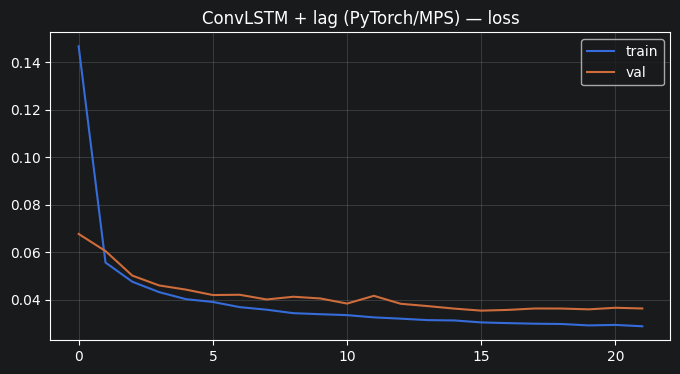

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history["loss"], label="train")
ax.plot(history["val_loss"], label="val")
ax.set_title("ConvLSTM + lag (PyTorch/MPS) — loss")
ax.legend()
ax.grid(True, alpha=0.3)
fig.savefig(OUT / "01_loss_curve.png", dpi=140)
plt.show()

## 5. Evaluate in °C

Validation RMSE (°C) by depth:
       0 m  0.145 °C
       5 m  0.120 °C
      10 m  0.119 °C
      20 m  0.137 °C
      30 m  0.150 °C
      50 m  0.174 °C
      75 m  0.222 °C
     100 m  0.250 °C
     125 m  0.252 °C
     150 m  0.217 °C
     200 m  0.165 °C
     300 m  0.374 °C
     500 m  0.350 °C
     700 m  0.339 °C
    1000 m  0.365 °C
mean RMSE: 0.225 °C
overall RMSE: 0.241 °C


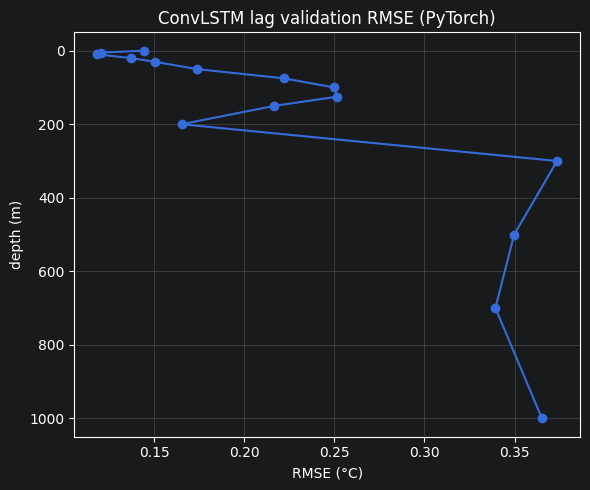

In [38]:
depths = depth_vals
sse = np.zeros(N_OUT, dtype=np.float64)
count = np.zeros(N_OUT, dtype=np.float64)

model.eval()
with torch.no_grad():
    for x, y_n, m in val_loader:
        pred_n = model(x.to(DEVICE)).cpu().numpy()
        y_n = y_n.numpy()
        m = m.numpy()
        pred = pred_n * y_std[:, None, None] + y_mean[:, None, None]
        y = y_n * y_std[:, None, None] + y_mean[:, None, None]
        diff2 = np.where(m, (pred - y) ** 2, 0.0)
        sse += diff2.sum(axis=(0, 2, 3))
        count += m.sum(axis=(0, 2, 3))

rmse = np.sqrt(sse / np.maximum(count, 1.0))
print("Validation RMSE (°C) by depth:")
for d, r in zip(depths, rmse):
    print(f"  {float(d):6.0f} m  {r:.3f} °C")
print(f"mean RMSE: {rmse.mean():.3f} °C")
print(f"overall RMSE: {np.sqrt(sse.sum() / count.sum()):.3f} °C")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rmse, depths, marker="o", label="ConvLSTM+lag")
ax.invert_yaxis()
ax.set_xlabel("RMSE (°C)")
ax.set_ylabel("depth (m)")
ax.set_title("ConvLSTM lag validation RMSE (PyTorch)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "02_rmse_by_depth.png", dpi=140)
plt.show()

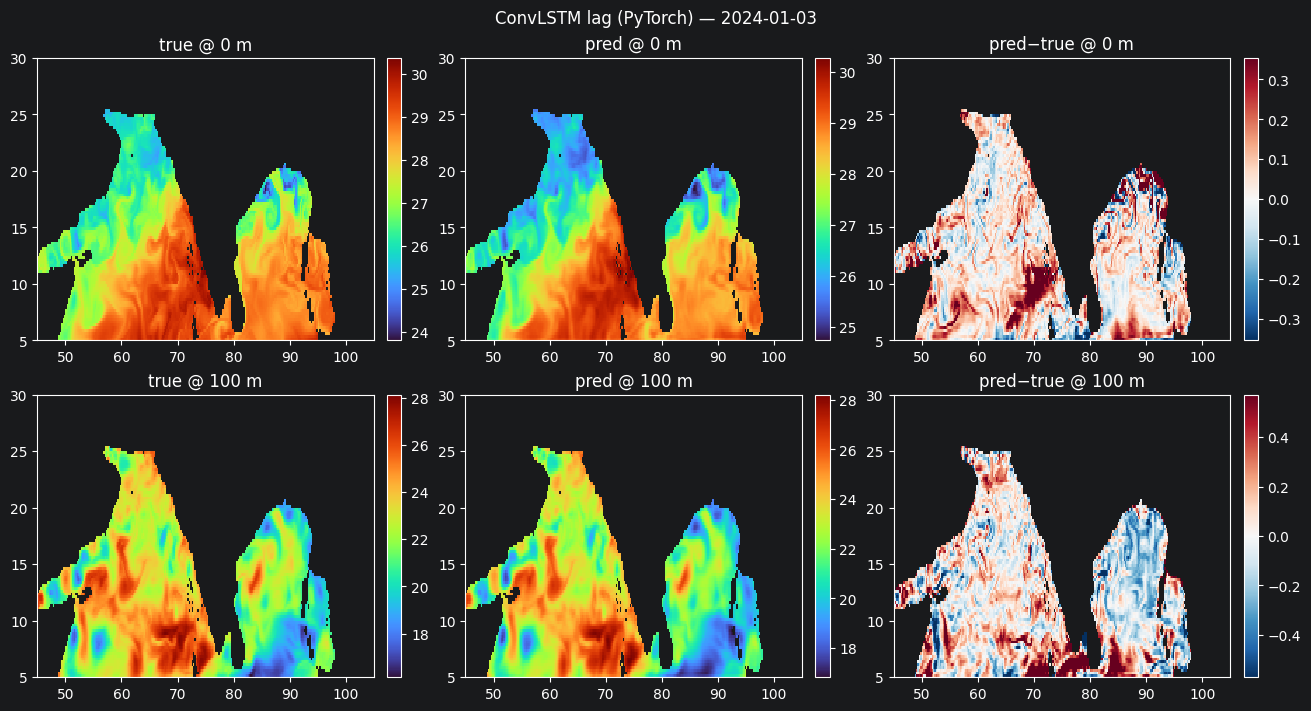

In [39]:
vi = len(val_idx) // 2
val_day = int(val_idx[vi])
x1, _, m1 = make_example(val_day)
model.eval()
with torch.no_grad():
    pred_n = model(torch.from_numpy(x1)[None].to(DEVICE)).cpu().numpy()[0]
pred_c = np.moveaxis(pred_n * y_std[:, None, None] + y_mean[:, None, None], 0, -1)
m1_hwc = np.moveaxis(m1, 0, -1)
true_c = y_all[val_day]
lon, lat = surface.longitude.values, surface.latitude.values
day_label = str(times[val_day])[:10]

fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)
for row, d in enumerate([0.0, 100.0]):
    di = int(np.where(depths == d)[0][0])
    truth = np.where(m1_hwc[..., di], true_c[..., di], np.nan)
    pred = np.where(m1_hwc[..., di], pred_c[..., di], np.nan)
    err = pred - truth
    for ax, field, title in zip(
        axes[row], [truth, pred, err],
        [f"true @ {d:.0f} m", f"pred @ {d:.0f} m", f"pred−true @ {d:.0f} m"],
    ):
        if "pred−true" in title:
            vmax = np.nanpercentile(np.abs(err), 95)
            im = ax.pcolormesh(lon, lat, field, shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        else:
            im = ax.pcolormesh(lon, lat, field, shading="auto", cmap="turbo")
        ax.set_title(title)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"ConvLSTM lag (PyTorch) — {day_label}")
fig.savefig(OUT / "03_maps_true_pred.png", dpi=140)
plt.show()

## 6. Closed-loop eval (daily rollout)

Teacher forcing (§5) feeds **true** GLORYS θ on `t−1`, `t−2`. That is **not** daily operations.

If the model runs every day, lags are **its own** yesterday/day-before maps. Walk the val days in order, cache predicted 0–200 m, and reuse that cache. First two days of each JFM season still spin up from GLORYS (no Dec 31 in this cube).

closed-loop days using own lags: 173/177
Closed-loop RMSE (°C) — own predictions as t−1, t−2:
       0 m  1.542 °C
       5 m  1.500 °C
      10 m  1.427 °C
      20 m  1.354 °C
      30 m  1.318 °C
      50 m  1.458 °C
      75 m  2.243 °C
     100 m  2.786 °C
     125 m  2.426 °C
     150 m  1.896 °C
     200 m  1.582 °C
     300 m  1.017 °C
     500 m  0.618 °C
     700 m  0.506 °C
    1000 m  0.455 °C
mean RMSE: 1.475 °C
overall RMSE: 1.613 °C
(§5 teacher-forced overall was 0.237 °C)


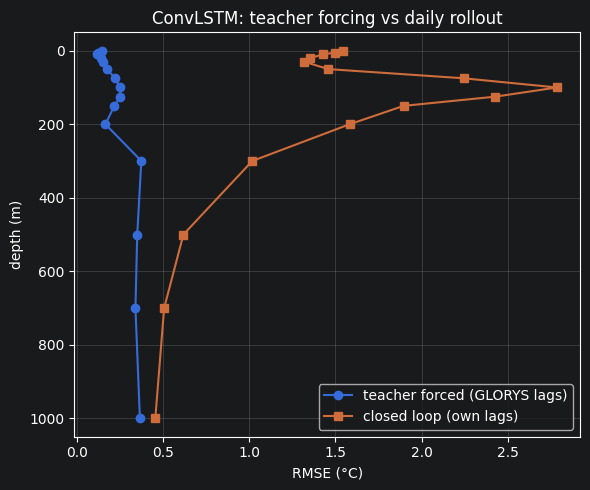

In [40]:
def make_example_loop(t: int, lag_shallow: dict[int, np.ndarray]):
    """Same as make_example, but lag θ comes from lag_shallow when present."""
    frames = []
    for lag in LAG_OFFSETS:
        tl = t - lag
        surf = x_surface[tl].astype(np.float32)
        if lag == 0:
            shallow = np.zeros((H, W, N_SHALLOW), dtype=np.float32)
        elif tl in lag_shallow:
            shallow = lag_shallow[tl]
        else:
            shallow = y_shallow[tl].astype(np.float32)
        frames.append(np.concatenate([surf, shallow], axis=-1))
    frames = np.stack(frames, axis=0)
    y = y_all[t].copy()

    x_ok = np.all(np.isfinite(frames), axis=(0, 3))
    y_ok = np.isfinite(y)
    mask = (y_ok & x_ok[..., None]).astype(np.float32)

    frames = (frames - frame_mean) / frame_std
    y = (y - y_mean) / y_std
    frames = np.nan_to_num(frames, nan=0.0).astype(np.float32)
    y = np.nan_to_num(y, nan=0.0).astype(np.float32)
    frames = np.moveaxis(frames, -1, 1)
    y = np.moveaxis(y, -1, 0)
    mask = np.moveaxis(mask, -1, 0)
    return frames, y, mask


sse_loop = np.zeros(N_OUT, dtype=np.float64)
count_loop = np.zeros(N_OUT, dtype=np.float64)
pred_shallow: dict[int, np.ndarray] = {}
n_own_lag = 0

model.eval()
with torch.no_grad():
    for t in val_idx:
        t = int(t)
        used_own = all((t - lag) in pred_shallow for lag in LAG_OFFSETS if lag > 0)
        n_own_lag += int(used_own)
        x1, y_n, m = make_example_loop(t, pred_shallow)
        pred_n = model(torch.from_numpy(x1)[None].to(DEVICE)).cpu().numpy()[0]
        pred_c = pred_n * y_std[:, None, None] + y_mean[:, None, None]
        y_c = y_n * y_std[:, None, None] + y_mean[:, None, None]
        diff2 = np.where(m, (pred_c - y_c) ** 2, 0.0)
        sse_loop += diff2.sum(axis=(1, 2))
        count_loop += m.sum(axis=(1, 2))
        # cache 0–200 m in °C for tomorrow (CHW → HWC shallow)
        pred_hwc = np.moveaxis(pred_c, 0, -1)
        pred_shallow[t] = pred_hwc[..., shallow_idx].astype(np.float32)

rmse_loop = np.sqrt(sse_loop / np.maximum(count_loop, 1.0))
print(f"closed-loop days using own lags: {n_own_lag}/{len(val_idx)}")
print("Closed-loop RMSE (°C) — own predictions as t−1, t−2:")
for d, r in zip(depth_vals, rmse_loop):
    print(f"  {float(d):6.0f} m  {r:.3f} °C")
print(f"mean RMSE: {rmse_loop.mean():.3f} °C")
print(f"overall RMSE: {np.sqrt(sse_loop.sum() / count_loop.sum()):.3f} °C")
print("(§5 teacher-forced overall was 0.237 °C)")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rmse, depth_vals, marker="o", label="teacher forced (GLORYS lags)")
ax.plot(rmse_loop, depth_vals, marker="s", label="closed loop (own lags)")
ax.invert_yaxis()
ax.set_xlabel("RMSE (°C)")
ax.set_ylabel("depth (m)")
ax.set_title("ConvLSTM: teacher forcing vs daily rollout")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "05_closed_loop_rmse.png", dpi=140)
plt.show()

## Artifacts

- Weights: `ml/checkpoints/convlstm_lag_jfm_2015_2024_lag_w32_best.pt`
- Norm: `ml/checkpoints/convlstm_lag_jfm_2015_2024_lag_w32_norm.npz`
- Figures: `outputs/convlstm_lag/`

**Daily ops:** surface for 3 days + **yesterday’s model θ (0–200 m)**, not GLORYS. First 2 days of each JFM season spin up from GLORYS. Report **closed-loop** RMSE (§6), not teacher-forced §5.